# Tests of the sliding diffusion concept

Experiments and tests of hyperparameter configurations

In [2]:
import torch
from diffusion import Diffusion
from v1_sliding_diffusion import SlidingDiffusion
from v1_normal_diffusion import NormalDiffusion

device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu")

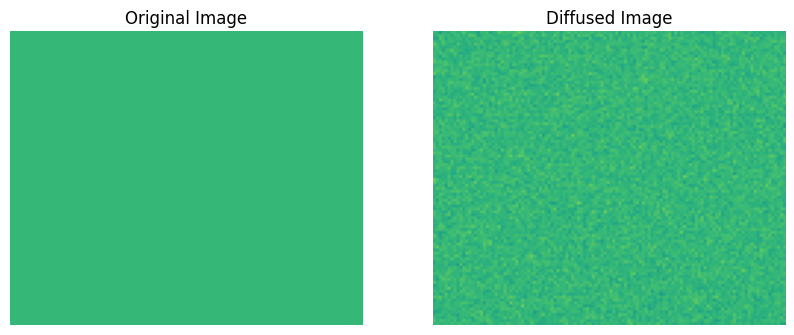

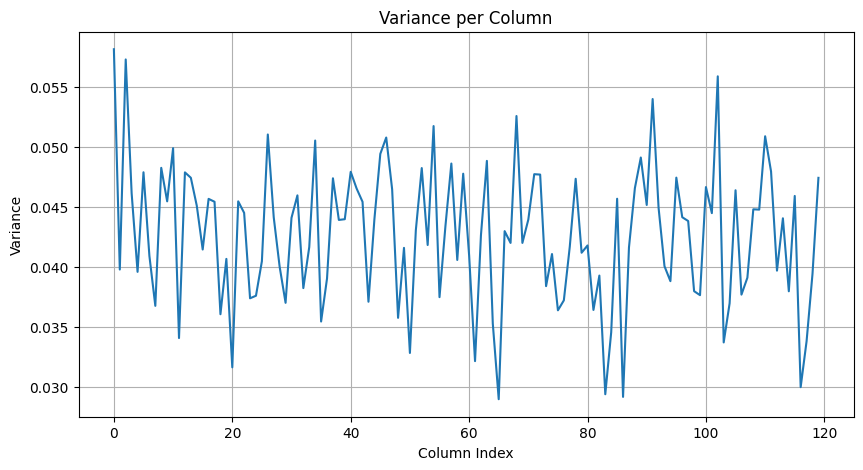

Average Variance: 0.04268769919872284


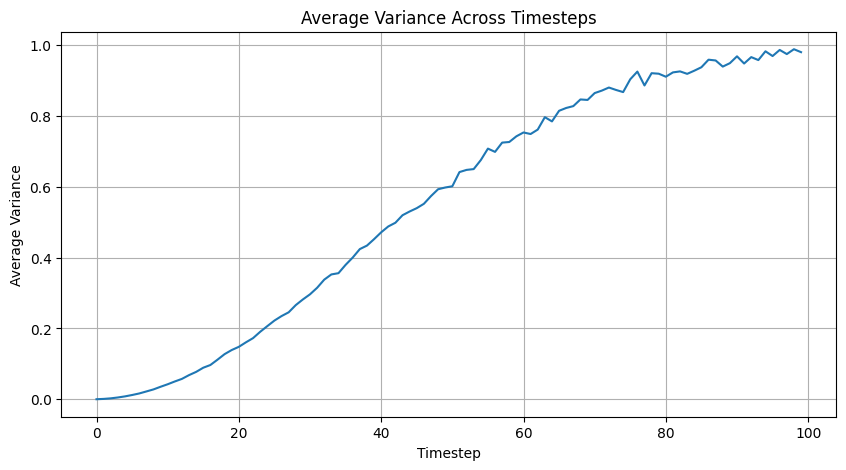

In [34]:
# Initialize the diffusion class
# diffusion = SlidingDiffusion(
#     num_clean_frames = 50, 
#     num_denoise_frames = 50, 
#     num_noise_frames = 20,
#     num_timestep_stackings = 10,
#     noise_schedule = Diffusion.linear_schedule(0.00015, 0.15), 
#    device = device 
# )

diffusion = NormalDiffusion(
    num_timesteps=100,
    sequence_length=120,
    noise_schedule=Diffusion.linear_schedule(0.00015, 0.075),
    device=device
)

# Create a tensor that is all white so we can see the noising process removing details
image = torch.ones((100, 120))
image = image.to(device)

# Run the forward diffusion function
transformed_image = diffusion.forward(sequence_tensor = image, timestep=10)

# Draw both images next to each other in the python notebook
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image.cpu().numpy(), vmin=-3, vmax=3)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(transformed_image.cpu().numpy(), vmin=-3, vmax=3)
ax[1].set_title("Diffused Image")
ax[1].axis("off")


if isinstance(diffusion, SlidingDiffusion):
    # Draw a vertical line at num_of_pre_timestep_frames
    line_x = diffusion.num_clean_frames
    for a in ax:
        a.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
        a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

    # Draw a vertical line at num_of_timestep_frames
    line_x = diffusion.num_clean_frames + diffusion.num_denoise_frames
    for a in ax:
        a.axvline(x=line_x, color='red', linestyle='--', label='Timestep frames')
        a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

plt.show()

# Calculate the variance per frame (vertical slice)
variances = torch.var(transformed_image, dim=0)

# Plot the variance for each column
plt.figure(figsize=(10, 5))
plt.plot(variances.cpu().numpy())
plt.title("Variance per Column")
plt.xlabel("Column Index")
plt.ylabel("Variance")
plt.grid(True)

if isinstance(diffusion, SlidingDiffusion):
    # Draw vertical lines at num_of_pre_timestep_frames and num_of_timestep_frames
    line_x = diffusion.num_clean_frames
    plt.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
    plt.axvline(x=line_x + diffusion.num_denoise_frames, color='red', linestyle='--', label='Timestep frames')

plt.show()

# print the average variance
print("Average Variance:", torch.mean(variances).item())


# plot the average variance across different timesteps
timesteps = torch.arange(0, diffusion.num_timesteps)
average_variance = torch.zeros(diffusion.num_timesteps)
for t in timesteps:
    transformed_image = diffusion.forward(sequence_tensor=image, timestep=t)
    average_variance[t] = torch.mean(torch.var(transformed_image, dim=0))

plt.figure(figsize=(10, 5))
plt.plot(timesteps.cpu().numpy(), average_variance.cpu().numpy())
plt.title("Average Variance Across Timesteps")
plt.xlabel("Timestep")
plt.ylabel("Average Variance")
plt.grid(True)
if isinstance(diffusion, SlidingDiffusion):
    # Draw vertical lines at num_of_pre_timestep_frames and num_of_timestep_frames
    line_x = diffusion.num_clean_frames
    plt.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
    plt.axvline(x=line_x + diffusion.num_denoise_frames, color='red', linestyle='--', label='Timestep frames')
plt.show()

In [3]:
num_of_timestap_stackings = 2
time_step_stacking_indexs = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] 
num_of_timestep_frames = 4

for time_step_stacking_index in time_step_stacking_indexs:
    timesteps_at_frames = [(t + 1) * num_of_timestap_stackings - (time_step_stacking_index % num_of_timestap_stackings) for t in range(num_of_timestep_frames)]
    print(timesteps_at_frames, " with size: ", len(timesteps_at_frames), " must be equal to: ", num_of_timestep_frames)  
    

[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4


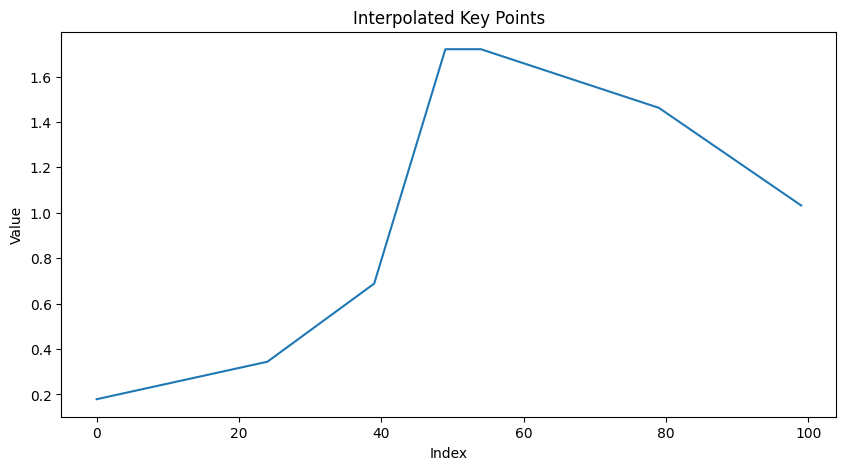

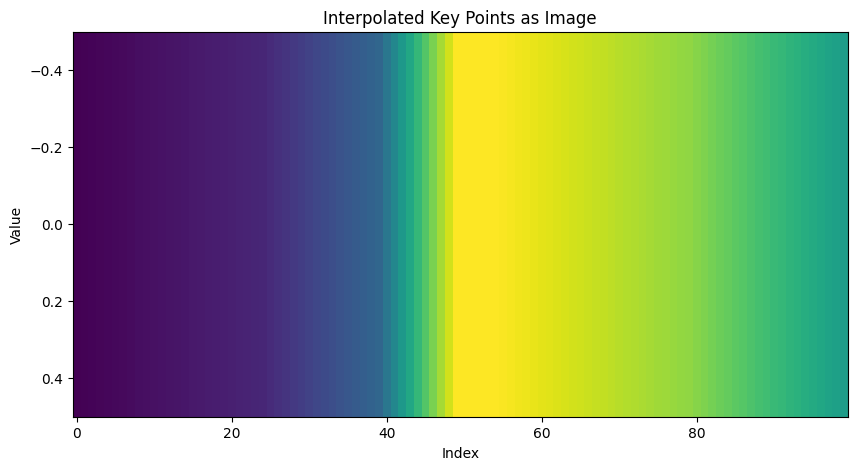

In [7]:
import matplotlib.pyplot as plt
import v1_traing_loop

# Now, segments_info contains (start, end, end_frame)
segments_info = [
    (0.1, 0.2, 25),
    (0.2, 0.4, 40),
    (0.4, 1.0, 50),
    (1.0, 1.0, 55),
    (1.0, 0.85, 80),
    (0.85, 0.6, 100)
]

result = v1_traing_loop.construct_frame_weighting_vector(segments_info)

# Draw the interpolation result
plt.figure(figsize=(10, 5))
plt.plot(result.numpy())
plt.title("Interpolated Key Points")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

# Draw the tensor as an image
plt.figure(figsize=(10, 5))
plt.imshow(result.unsqueeze(0).numpy(), aspect='auto', cmap='viridis')
plt.title("Interpolated Key Points as Image")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()